In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import plotly.graph_objects as go
# from tqdm import tqdm
from network_funcs import *
from qopt_funcs import *
import networkx as nx
# import random
import time
import shutil    # to copy files at the end of the script

### Define a better visualization function (to be integrated in network_funcs)

In [42]:
def plot_network(cartesian_coords, rate_matrix, R, filename='earth', caption='',
                         bckgrnd_color = 'midnightblue', pt_color='yellow', edge_color='white'):    # ft chatgpt
    # could be improved, eg R must be the length of the coords vecs so its just messy to input it separately
    from matplotlib import cm
    from matplotlib.colors import Normalize

    def linewidth_from_rate(rate, cost=3.):
        return (np.log(rate/np.min(rate_matrix[rate_matrix>0])) / np.log(np.max(rate_matrix[rate_matrix>0])/np.min(rate_matrix[rate_matrix>0]))) * cost    # log scale for better visibility, but not too much

    deg_distr = np.sum(rate_matrix > 0, axis=1)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # generate cartesian coords arrays
    x = cartesian_coords[:, 0]
    y = cartesian_coords[:, 1]
    z = cartesian_coords[:, 2]
    # represent transparent sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = R * np.outer(np.cos(u), np.sin(v))
    y_sphere = R * np.outer(np.sin(u), np.sin(v))
    z_sphere = R * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere, color='blue', alpha=0.2)
    # represent points
    ax.scatter(x, y, z, s=np.log(deg_distr+1)*50, color=pt_color)
    # represent paths between points as geodetic curves
    n_points = cartesian_coords.shape[0]

    dists = []

    for i in range(n_points):
        for j in range(i+1, n_points):
            if rate_matrix[i, j] > 0:
                phi = np.arccos(np.dot(cartesian_coords[i], cartesian_coords[j]) / (R**2))
                dists.append(phi)

    dists = np.array(dists)

    norm = Normalize(vmin=dists.min(), vmax=dists.max())
    cmap = cm.inferno_r

    for i in range(n_points):
        for j in range(i+1, n_points):
            if rate_matrix[i, j] > 0:
                phi = np.arccos(np.dot(cartesian_coords[i], cartesian_coords[j]) / (R**2))    # the angle bw the 2 vecs
                t = np.linspace(0, phi, 100)               # for the parametric curve
                x_arc = np.sin(t) * (cartesian_coords[i, 0] / np.sin(phi)) + np.sin(phi - t) * (cartesian_coords[j, 0] / np.sin(phi))
                y_arc = np.sin(t) * (cartesian_coords[i, 1] / np.sin(phi)) + np.sin(phi - t) * (cartesian_coords[j, 1] / np.sin(phi))
                z_arc = np.sin(t) * (cartesian_coords[i, 2] / np.sin(phi)) + np.sin(phi - t) * (cartesian_coords[j, 2] / np.sin(phi))
                color = cmap(norm(phi))
                ax.plot(x_arc, y_arc, z_arc, color=color, alpha=0.7, linewidth=linewidth_from_rate(rate_matrix[i, j]))    # thicker for higher rates, but not too much
    # require same scale for all axes
    ax.set_xlim([-R, R])
    ax.set_ylim([-R, R])
    ax.set_zlim([-R, R])
    ax.set_box_aspect([1, 1, 1])
    ax.axis('off')
    #plt.rcParams['figure.figsize'] = [15,15]
    fig.set_size_inches(8,8)
    ax.set_facecolor(bckgrnd_color)
    #plt.show()            # interactive 3d mode (not compatible w savefig)
    fig.text(.5, .15, s=caption, color=edge_color, fontsize=30)
    output_dir = 'earth_frames'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    if not os.path.exists(output_dir + '/' + bckgrnd_color):
        os.makedirs(output_dir + '/' + bckgrnd_color)
    filename = 'earth_frames/' + bckgrnd_color + '/' + filename + '.png'
    plt.savefig(filename, dpi=300, transparent=True)
    plt.show()             # cuidado! shows a plot every fctn call
    plt.close()

    return


# entanglement rate vs $\rho$

optimal probability is 2.0487233913658014e-05 for radius 75.39300438651343 with path [0, 31, 27, 99]
optimal probability is 0.00031155948450094066 for radius 45.196918713941635 with path [0, 31, 27, 99]
optimal probability is 0.0015928171424506765 for radius 27.094840931953417 with path [0, 31, 27, 99]
optimal probability is 0.004236189843786652 for radius 16.24293040360305 with path [0, 31, 27, 99]
optimal probability is 0.007614510948619947 for radius 9.73738095598671 with path [0, 31, 27, 99]
optimal probability is 0.010822077300978748 for radius 5.8374065224696245 with path [0, 31, 27, 99]
optimal probability is 0.013360818448666666 for radius 3.4994332729296005 with path [0, 31, 27, 99]
optimal probability is 0.01516000409508289 for radius 2.0978551321633603 with path [0, 31, 27, 99]
optimal probability is 0.016352749155735334 for radius 1.2576311111826945 with path [0, 31, 27, 99]
optimal probability is 0.017112311803755633 for radius 0.7539300438651343 with path [0, 31, 27, 99]


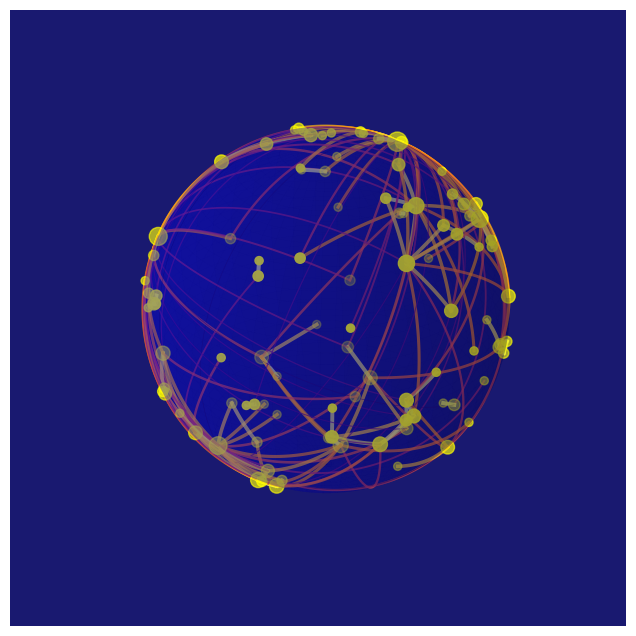

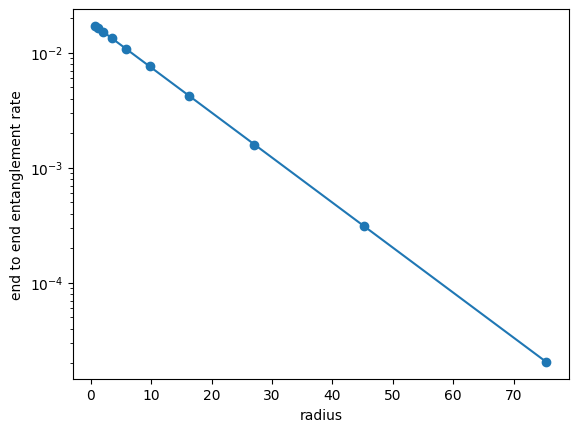

In [43]:
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233                   # \mu param of S2 model
N=100

pBell = 0.5

rhos = 0.14*10**np.linspace(-2,2,10)
radii = np.sqrt(N/4/np.pi/rhos)

# for it in range(n_iter):    # indent back below for multiple iterations
probs = []

A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)
n_nodes_giant = []                                   # nr of nodes in largest (giant) component
clustering_list = []
rate_sum_accum = []
rate_sq_sum_accum = []
for radius in radii:
    alice = 0
    bob = N-1
    T = np.zeros_like(A)                    # matrix of the graph weights ie the inverse rates (s/bit)
    for i in range(N):
        for j in range(i):
            if A[i,j] == 1:
                dij = radius*Dists[i,j]
                T[i,j] = T[j,i] = transmittance_v_distance(dij)
    #plot_graph_on_sphere(coords, A_pruned, 1, filename='earth_radius%.2f' % radius)    # makes things slower
    G_pruned = nx.from_numpy_array(T)          # return a weighted graph object
    opt_prob, opt_path = optimal_quantum_repeater_path(T, pBell, alice, bob)

    print(f'optimal probability is {opt_prob} for radius {radius} with path {opt_path}')
    probs.append(opt_prob)


plot_network(coords, T, 1, filename='earth_radius%.2f' % radius)    # drawing the last network, just for visualization

plt.plot(radii, probs, marker='o')
plt.xlabel('radius')
plt.ylabel('end to end entanglement rate')
plt.yscale('log')
    


# entanglement rate and shortest path length vs $p_{BSM}$

Text(0.5, 0, 'BSM success probability')

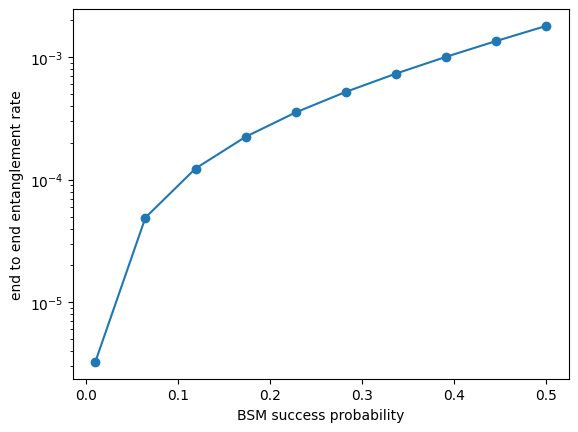

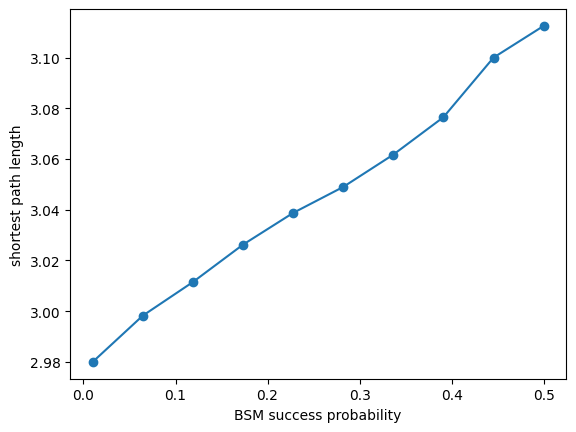

In [14]:
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233                   # \mu param of S2 model
N=400
n_iter= 10                    # to accumulate statistics

p_Bells = np.linspace(0.01, .5, 10)

rhos = 10**np.linspace(-2., 1,1)
radii = np.sqrt(N/4/np.pi/rhos)

# for it in range(n_iter):    # indent back below for multiple iterations
all_probs = {pb: [] for pb in p_Bells}
all_spls = {pb: [] for pb in p_Bells}                 # average shortest path lengths

for instance in range(n_iter):
    for radius in radii:
        A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)
        T = np.zeros_like(A)                    # matrix of the graph weights ie the inverse rates (s/bit)
        for i in range(N):
            for j in range(i):
                if A[i,j] == 1:
                    dij = radius*Dists[i,j]
                    T[i,j] = T[j,i] = transmittance_v_distance(dij)
        for p_Bell in p_Bells:
            probs, paths = optimal_quantum_repeater_path(T, p_Bell, alice)
            
            spls = [len(path)-1 for path in paths.values()]                   # shortest path lengths

            all_probs[p_Bell].append(list(probs.values()))
            all_spls[p_Bell].append([len(path)-1 for path in paths.values()])


# plot_network(coords, T, 1, filename='earth_radius%.2f' % radius)    # drawing the last network, just for visualization

plt.plot(p_Bells, [np.average(all_probs[pb]) for pb in p_Bells], marker='o')
plt.yscale('log')
plt.ylabel('end to end entanglement rate')
plt.xlabel('BSM success probability')

plt.figure(2)
plt.plot(p_Bells, [np.average(all_spls[pb]) for pb in p_Bells], marker='o')
plt.ylabel('shortest path length')
plt.xlabel('BSM success probability')

    


In [ ]:
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233                   # \mu param of S2 model
N=200
n_iter= 5                    # to accumulate statistics

p_Bells = np.linspace(0.01, .5, 8)

rhos = 10**np.linspace(-2., 1,8)
radii = np.sqrt(N/4/np.pi/rhos)

# to store results:
all_probs = {(rad, pb): [] for pb in p_Bells for rad in radii}
all_spls = {(rad, pb): [] for pb in p_Bells for rad in radii}                 # average shortest path lengths

heatmap_probs, heatmap_spls = np.zeros((len(radii), len(p_Bells))), np.zeros((len(radii), len(p_Bells)))    # to store the probabilities for the heatmap

for instance in range(n_iter):
    for r, radius in enumerate(radii):
        A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)
        T = np.zeros_like(A)                    # matrix of the graph weights ie the inverse rates (s/bit)
        for i in range(N):
            for j in range(i):
                if A[i,j] == 1:
                    dij = radius*Dists[i,j]
                    T[i,j] = T[j,i] = transmittance_v_distance(dij)
        #plot_graph_on_sphere(coords, A_pruned, 1, filename='earth_radius%.2f' % radius)    # makes things slower
        # G_pruned = nx.from_numpy_array(T)          # return a weighted graph object
        for p, p_Bell in enumerate(p_Bells):
            probs, paths = optimal_quantum_repeater_path(T, p_Bell, alice)    # ITERATE ON ALICE? use nx average_shortest_path_length fctn
            
            spls = [len(path)-1 for path in paths.values()]                   # shortest path lengths

            # these are lists of lists (for each tuple, there is a list for each instance of the network)
            all_probs[(radius, p_Bell)].append(list(probs.values()))
            all_spls[(radius, p_Bell)].append([len(path)-1 for path in paths.values()])
            
# we want the average
for r, radius in enumerate(radii):
    for p, p_Bell in enumerate(p_Bells):
        heatmap_probs[r,p] = np.average(all_probs[(radius, p_Bell)])
        heatmap_spls[r,p] = np.average(all_spls[(radius, p_Bell)])


[[0.00130199680414211, 8.944123012524735e-07, 5.774663388948085e-07, 2.8640701672544874e-08, 9.780660061169316e-10, 8.869613945510219e-10, 7.991255422699874e-10, 6.449727213200023e-10, 5.273960347153264e-10, 5.201916310943085e-10, 5.085138900772839e-10, 4.1871705829217216e-10, 1.9430063594925851e-10, 1.736696774564071e-10, 1.1133030424348661e-10, 2.5647299060154792e-11, 2.512723457348836e-11, 8.406703285903472e-12, 6.637077606935414e-12, 4.110045597499626e-12, 2.923927239469983e-12, 2.0729193752193e-12, 4.947222443642083e-13, 4.1018817158194733e-13, 2.729381697927937e-13, 2.2625064138262672e-13, 1.8009326254139115e-13, 1.647712206168354e-13, 1.4934281982964905e-13, 1.2298049367773424e-13, 1.1636578830649113e-13, 1.0863296890028506e-13, 9.404743803825177e-14, 9.206892632192068e-14, 7.914950755629204e-14, 7.632103805953233e-14, 7.495536877979835e-14, 7.204538073473569e-14, 7.068541148245944e-14, 6.218360210832636e-14, 6.079629067744537e-14, 5.768067682268236e-14, 4.7335533495198995e-14, 

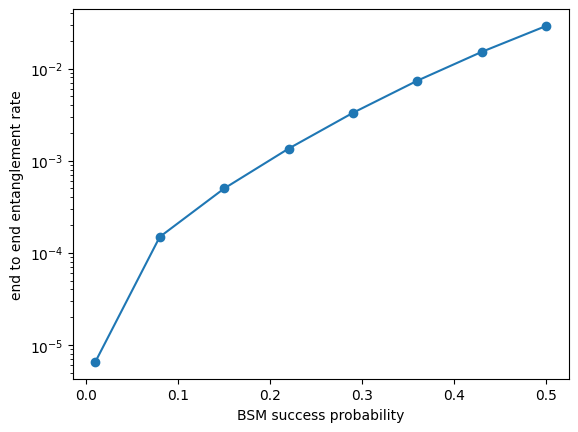

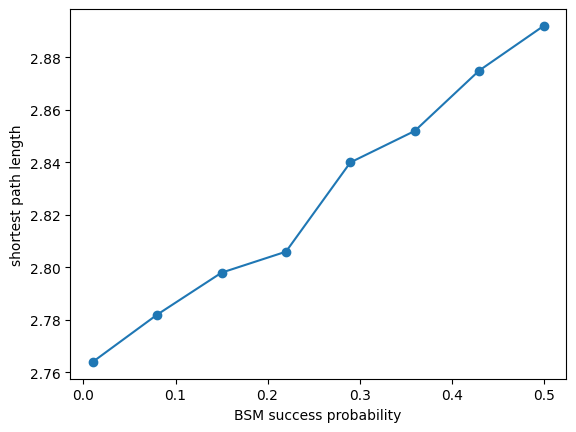

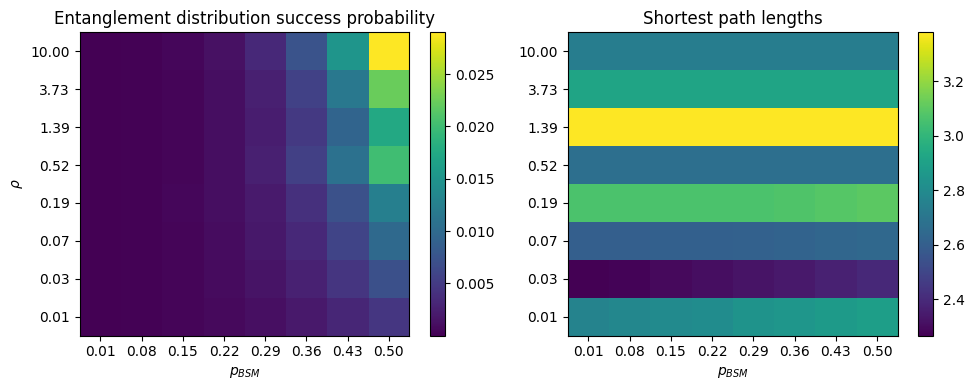

In [28]:

# plot_network(coords, T, 1, filename='earth_radius%.2f' % radius)    # drawing the last network, just for visualization

plt.plot(p_Bells, heatmap_probs[-1], marker='o')
plt.yscale('log')
plt.ylabel('end to end entanglement rate')
plt.xlabel('BSM success probability')

plt.figure(2)
plt.plot(p_Bells, heatmap_spls[0], marker='o')
plt.ylabel('shortest path length')
plt.xlabel('BSM success probability')

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# format labels (1 decimal)
xticklabels = [f"{v:.2f}" for v in p_Bells]
yticklabels = [f"{v:.2f}" for v in rhos]

# heatmap 1
im0 = axes[0].imshow(heatmap_probs, cmap='viridis', origin='lower', aspect='auto')
axes[0].set_title('Entanglement distribution success probability')
axes[0].set_xlabel(r'$p_{BSM}$')
axes[0].set_ylabel(r'$\rho$')
axes[0].set_xticks(range(len(p_Bells)))
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(range(len(rhos)))
axes[0].set_yticklabels(yticklabels)
plt.colorbar(im0, ax=axes[0])

# heatmap 2
im1 = axes[1].imshow(heatmap_spls, cmap='viridis', origin='lower', aspect='auto')
axes[1].set_title('Shortest path lengths')
axes[1].set_xlabel(r'$p_{BSM}$')
axes[0].set_ylabel(r'$\rho$')
axes[1].set_xticks(range(len(p_Bells)))
axes[1].set_xticklabels(xticklabels)
axes[1].set_yticks(range(len(rhos)))
axes[1].set_yticklabels(yticklabels)
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# print(heatmap_probs)
# print(heatmap_spls)


In [9]:
from qopt_funcs import *

func_CV = lambda dist : hybrid_keyrate_bitpersec(state_of_the_art_params, dist, d_hybrid = float('inf'))
# d_c_CV = bisection_solver(func_CV, 10E-06, d_max)            # not starting from 0 bc if T=1 there is a division by 0
func_DV = lambda dist : hybrid_keyrate_bitpersec(state_of_the_art_params, dist, d_hybrid = 0)
# d_c_DV = bisection_solver(func_DV, 10E-06, d_max)
diff = lambda d: func_CV(d) - func_DV(d)
d_cross = bisection_solver(diff, 10E-06, 1000)
d_cross

46.805361504526445

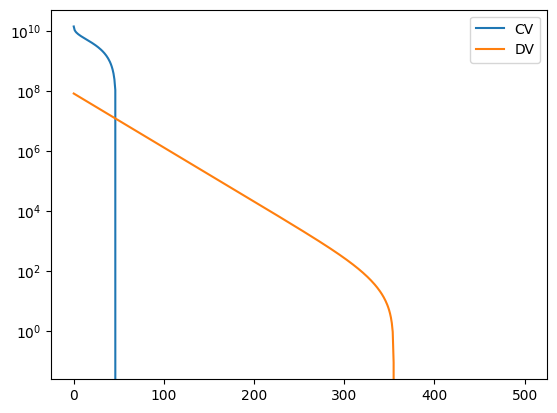

In [13]:
xs = np.linspace(0.01, 500, 500)
plt.plot(xs, [func_CV(x) for x in xs], label='CV')
plt.plot(xs, [func_DV(x) for x in xs], label='DV')
plt.legend()
plt.yscale('log')
